# Lagos Real Estate Market Analysis
**Author**: Mayowa Daniel | **Date**: June 2026 | 
**Data Source**: Web scraped from [NigeriaPropertyCentre](https://nigeriapropertycentre.com/)
**GitHub**: [Real_Estate_Market_Analysis](https://github.com/dtechtitan/Real_Estate_Market_Analysis)

---

## Project Overview
The Lagos real estate market is one of the most dynamic and complex property markets 
in Africa, shaped by rapid urbanization, infrastructure gaps, and wide income disparity 
across neighborhoods. Despite this, publicly available structured data on Lagos property 
prices remains scarce.

This project scrapes live property listings from NigeriaPropertyCentre and performs 
an end-to-end exploratory analysis — uncovering pricing patterns, location trends, 
and the key drivers of property value across Lagos.

---

## Research Questions
1. Does location significantly affect property price? (e.g. Lekki vs Surulere vs Yaba)
2. Does property type (flat, duplex, detached house) influence pricing?
3. What does a "typical" Lagos property look like in terms of bedrooms, 
   bathrooms, and price range?
4. Which locations appear underpriced or overpriced relative to what they offer?
5. Which property features (bedrooms, bathrooms, size) correlate most strongly with price?

---

## Tools & Libraries
| Tool | Purpose |
|---|---|
| `requests` + `BeautifulSoup` | Web scraping |
| `pandas` + `numpy` | Data manipulation and analysis |
| `matplotlib` + `seaborn` | Data visualization |
| `Jupyter Notebook` | Development environment |

In [93]:
# importing Cell

import time
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import requests
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt

# display settings
pd.set_option("display.max_columns", None)
sns.set_style

print("libraries loaded successfully")

libraries loaded successfully


## 1. Data Inspection

Before cleaning or analyzing the data, we first need to understand what we're working with. This section examines the raw scraped dataset to identify structural issues, missing values, and data type problems that will inform our cleaning strategy in the next section.

### What We Check
- **Shape** — how many rows and columns we collected
- **Data Types** — whether each column is stored in the correct format
- **Statistical Summary** — min, max, mean and spread of numerical columns
- **Missing Values** — which columns have gaps and how severe they are
- **Duplicates** — whether any listings were scraped more than once

In [94]:
df = pd.read_csv("../data/lagosIsland.csv")

In [95]:
# Shape
print(f"The dataframe has {df.shape[0]} rows and {df.shape[1]} columns \n")

# Data Type
print("Data Type:")
print(f"{df.dtypes} \n")

# Missing Values
print(f"We have {df.isnull().sum()} missing values \n")

# Duplicates
print(f"{df.duplicated().sum()} duplicates")

The dataframe has 20500 rows and 9 columns 

Data Type:
Title             object
Price             object
Location          object
Bedrooms          object
Bathrooms        float64
Property_Type     object
URL               object
Toilets          float64
Parking_Space     object
dtype: object 

We have Title                0
Price                0
Location             0
Bedrooms         12211
Bathrooms        12969
Property_Type        0
URL                  0
Toilets          12743
Parking_Space    16136
dtype: int64 missing values 

2528 duplicates


In [96]:
# Statistical summary
df.describe()

,Bathrooms,Toilets
count,7531.000000,7757.000000
mean,4.312575,5.153925
std,4.453988,4.608698
min,1.000000,1.000000
25%,3.000000,4.000000
50%,4.000000,5.000000
75%,5.000000,6.000000
max,150.000000,150.000000


### Observations - What did the inspection reveal?

- **Shape**: We collected 20,500 rows across 9 columns — a solid dataset for analysis and modelling.

- **Data Types**: All columns are stored as `object` (string) type. This is expected from web scraping but requires fixing — Price, Bedrooms, Bathrooms, Toilets and Parking Space all need to be converted to numeric types before any analysis can be performed.

- **Missing Values**: No NaN values were detected, however this is misleading. Missing data was filled with the string `"N/A"` during scraping. These need to be replaced with actual NaN values so Pandas can handle them properly.

- **Duplicates**: 2,528 duplicate rows were found — approximately 12% of the dataset. These are likely caused by promoted listings appearing across multiple pages during scraping and must be removed.

## 2. Data Cleaning

Raw scraped data is rarely analysis-ready. This section addresses the structural and quality issues identified during inspection, transforming the raw dataset into a clean, reliable foundation for exploratory analysis and modelling.

### Cleaning Steps
- **Drop Duplicates** — remove the 2,528 duplicate listings caused by promoted properties appearing across multiple pages
- **Replace "N/A" strings** — convert all "N/A" placeholder values to actual NaN so Pandas can handle them correctly
- **Visualise Missing Values** — after replacing "N/A" with NaN, plot the true missing value distribution across all columns
- **Clean Price Column** — remove currency symbols (₦, $), commas, and whitespace then convert to numeric. Handle mixed currency listings (NGN vs USD) with a clear decision
- **Clean Numeric Columns** — strip text labels like "Beds", "Baths", "Toilets" from Bedrooms, Bathrooms, Toilets and Parking Space columns then convert to numeric
- **Clean Location Column** — standardise casing and replace URL-style hyphens (e.g. "ikate-elegushi" → "Ikate Elegushi") for readability

### Goal
A clean DataFrame with correct data types, no duplicates, no placeholder strings, and consistent formatting — ready for EDA and modelling.

#### 2.1 Drop Duplicates

In [97]:
df.drop_duplicates(inplace=True)
print(f"Rows after dropping duplicates: {df.shape[0]}")

Rows after dropping duplicates: 17972


#### 2.2 Replace "N/A" strings

In [98]:
df = df.replace("N/A", np.nan, regex=False)

In [99]:
df.isna().sum()

Title                0
Price                0
Location             0
Bedrooms         10132
Bathrooms        10888
Property_Type        0
URL                  0
Toilets          10663
Parking_Space    13912
dtype: int64

#### 2.3 Visualise missing data

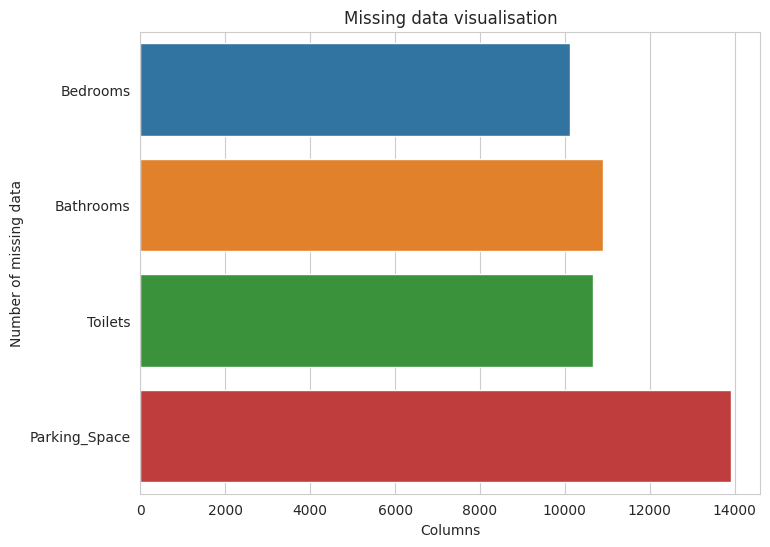

<Figure size 640x480 with 0 Axes>

In [100]:
all_missing = df.isna().sum()
missing_count = all_missing[all_missing > 0]

plt.figure(figsize = (8, 6))
sns.barplot(x = missing_count, y = missing_count.index, hue=missing_count.index, legend=False, orient="h")

plt.xlabel("Columns")
plt.ylabel("Number of missing data")
plt.title("Missing data visualisation")
plt.show()
plt.savefig("../visuals/missing_data_visualisation.png", bbox_inches='tight')

#### 2.4 Dropping land and other commercial listings

In [101]:
# Dropping rows where is land listing

df = df[~df["Property_Type"].str.contains("land", case = False)]

df["Property_Type"].value_counts()

Property_Type
Detached duplex for sale                         5730
Flat / apartment for sale                        3311
Terraced duplex for sale                         2252
Semi-detached duplex for sale                    2103
Block of flats for sale                           919
House for sale                                    798
Detached bungalow for sale                        338
Mini flat (room and parlour) for sale             142
Hotel / guest house for sale                      102
Commercial property for sale                       82
Semi-detached bungalow for sale                    58
Warehouse for sale                                 51
Plaza / complex / mall for sale                    51
Self contain (single rooms) for sale               41
Office space for sale                              33
Filling station for sale                           28
School for sale                                    20
Shop for sale                                      19
Factory for sa

In [102]:
# Keeping only the main listings and removing other property types

main_listing = ["Detached duplex for sale", "Flat / apartment for sale","Terraced duplex for sale","Semi-detached duplex for sale","Block of flats for sale","House for sale","Detached bungalow for sale","Mini flat (room and parlour) for sale","Semi-detached bungalow for sale","Terraced bungalow for sale","Self contain (single rooms) for sale"]

df = df[df["Property_Type"].isin(main_listing)]

#### 2.5 Clean price columns

In [103]:
df.head()

,Title,Price,Location,Bedrooms,Bathrooms,Property_Type,URL,Toilets,Parking_Space
0,Standard 3 Bedroom Off-Plan Apartments,"₦350,000,000","lekki-phase-1, lekki, lagos",3,3.0,Flat / apartment for sale,https://nigeriapropertycentre.com/for-sale/fla...,4.0,2
1,Luxury 5 Bedroom Semi Detached Duplex + BQ in ...,"₦350,000,000","lekki, lagos, semi-detached-duplexes",NaN,NaN,Semi-detached duplex for sale,https://nigeriapropertycentre.com/for-sale/hou...,NaN,NaN
2,Luxury 5 Bedroom Semi Detached Duplex + BQ in ...,"₦350,000,000","lekki, lagos, semi-detached-duplexes",5,5.0,Semi-detached duplex for sale,https://nigeriapropertycentre.com/for-sale/hou...,6.0,2
3,"Luxury 2 Bedroom Apartment with Pool, Elevator...","₦120,000,000","lekki, lagos",NaN,NaN,Flat / apartment for sale,https://nigeriapropertycentre.com/for-sale/fla...,NaN,NaN
4,"Luxury 2 Bedroom Apartment with Pool, Elevator...","₦120,000,000","lekki, lagos",2,2.0,Flat / apartment for sale,https://nigeriapropertycentre.com/for-sale/fla...,3.0,2


In [104]:
# Drop listings that are dollar priced
df = df[~df["Price"].str.contains("$", regex = False)]

# Remove "₦" and commas
df["Price"] = df["Price"].str.replace("₦","", regex=False).str.replace(",", "", regex=False)

# Converting  price data type to int
df["Price"] = df["Price"].astype(int) 

In [105]:
df.dtypes

Title             object
Price              int64
Location          object
Bedrooms          object
Bathrooms        float64
Property_Type     object
URL               object
Toilets          float64
Parking_Space     object
dtype: object

#### 2.6 Clean Numeric columns

In [106]:
df.columns

Index(['Title', 'Price', 'Location', 'Bedrooms', 'Bathrooms', 'Property_Type',
       'URL', 'Toilets', 'Parking_Space'],
      dtype='object')

In [107]:
# Apart from Price column other Numeric columns includes Toilet, Bedroom, Bathroom and Parking Space columns
columns = ["Toilets", "Bedrooms", "Bathrooms", "Parking_Space"]

for column in columns:
  df[column] = pd.to_numeric(df[column], errors="coerce")


In [108]:
df.dtypes

Title             object
Price              int64
Location          object
Bedrooms         float64
Bathrooms        float64
Property_Type     object
URL               object
Toilets          float64
Parking_Space    float64
dtype: object

#### 2.7 Clean Location columns

In [109]:
# Removing property types from the location column
df["Location"] = df["Location"].apply(
    lambda x: ", ".join([
        p for p in x.split(",") 
        if not any(word in p.lower() for word in ["duplexes", "bungalows", "apartments", "flats", "houses", "blocks", "bungalo", "detached", "terraced", "semi", "of-flats"])
    ])
)

# Removing hyphens and title-casing the location names
df["Location"] = df["Location"].str.replace("-", " ", regex=False)
df["Location"] = df["Location"].str.title()

# Only keeping listings that are located in Lagos state 
df = df[df["Location"].str.contains("Lagos", case=False)]

In [110]:
df.shape

(14997, 9)

### Observations

The raw scraped dataset required significant cleaning across multiple dimensions before it could be considered analysis-ready. The following changes were made:

- **Duplicates Removed** — 2,528 duplicate listings were dropped, reducing the dataset from 20,500 rows to approximately 18,000. These were caused by promoted listings appearing across multiple pages during scraping.

- **Land and commercial Listings Removed** — All property types containing the word "land" and commercial keywords were filtered out, Listings with "Lagos" keyword were kept. Land and commercial listings do not have bedrooms, bathrooms or toilets by nature and would distort any residential price analysis.

- **Dollar Listings Removed** — Listings priced in USD were dropped since reliable NGN conversion without a fixed exchange rate would introduce inaccurate data.

- **Price Cleaned** — The ₦ symbol and comma separators were removed and the Price column was successfully converted from object to int64.

- **Numeric Columns Cleaned** — Bedrooms, Bathrooms, Toilets and Parking Space were converted from object to float64. "NA" placeholder values were replaced with NaN to correctly represent missing data.

- **Location Cleaned** — Property type slugs leaked from URL extraction were removed, hyphens were replaced with spaces, and title casing was applied for consistency. Listings located outside Lagos (Ogun, Oyo and other states) were also removed.

- **Remaining Missing Values** — Bedrooms, Bathrooms, Toilets and Parking Space still contain significant missing values. These will not be imputed at this stage — NaN rows will be excluded naturally during EDA visualisations and a separate filtered DataFrame will be created for the prediction model.

### Dataset After Cleaning

The cleaned dataset contains **14, 997 rows** and **9 columns** — down from 20,500 raw scraped rows. This represents a reduction of approximately 27%, accounting for duplicates, land and commercial listings, dollar-priced listings, and out-of-Lagos listings that were removed.

All data types are now correct:
- **Price** → int64
- **Bedrooms, Bathrooms, Toilets, Parking_Space** → float64
- **Title, Location, Property_Type, URL** → object

The dataset is now clean and ready for Exploratory Data Analysis.

## 3. Exploratory Data Analysis (EDA)

With a clean dataset in hand, we now move into Exploratory Data Analysis — 
the process of visually and statistically examining the data to uncover 
patterns, trends, and relationships. This section directly addresses the 
five research questions defined at the start of the project.

EDA is the most important step before modelling — it tells us which features 
matter, how prices are distributed, which locations dominate the market, and 
where the data behaves unexpectedly. Every chart here is tied to a specific 
business question about the Lagos real estate market.

---

### Research Questions

1. Does location significantly affect property price? (e.g. Lekki vs Surulere vs Yaba)
2. Does property type (flat, duplex, detached house) influence pricing?
3. What does a "typical" Lagos property look like in terms of bedrooms, bathrooms, and price range?
4. Which locations appear underpriced or overpriced relative to what they offer?
5. Which property features (bedrooms, bathrooms, size) correlate most strongly with price?

---

### Visualisation
- **Price Distribution** → Q3 — understanding the spread and skewness of property 
  prices across Lagos. Histogram showuing price spread and skewness
- **Property Type vs Price** → Q2 — how different property types compare in average 
  price (average price per property type)
- **Location Analysis** → Q1 — which neighbourhoods command the highest and lowest 
  prices (average price per neighbourhood)
- **Bedroom & Bathroom Trends** → Q5 — how room count relates to property price 
- **Feature Correlation** → Q5 — which numeric features have the strongest 
  relationship with price
- **Underpriced vs Overpriced Locations** → Q4 — which areas offer value relative 
  to the Lagos average (location vs market average)

#### 3.1. Price Distribution

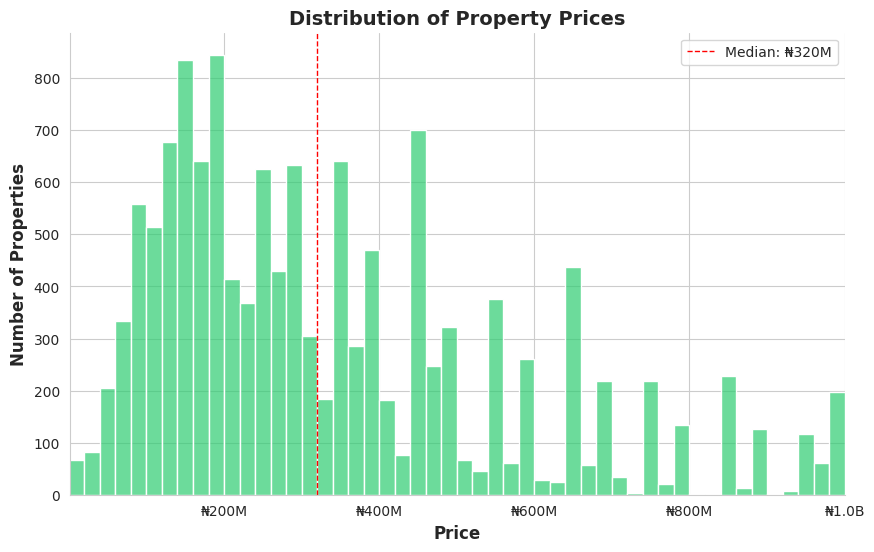

<Figure size 640x480 with 0 Axes>

In [111]:
df_plot = df[df["Price"] <= 1_000_000_000]

plt.figure(figsize = (10, 6))
sns.histplot(data = df_plot, x = 'Price', bins = 50, edgecolor = 'white', color = '#2ecc71', alpha = 0.7)
plt.title("Distribution of Property Prices", fontsize = 14, fontweight = 'bold')
plt.xlabel("Price", fontsize = 12, fontweight = 'bold')
plt.xlim(1_000_000, 1_000_000_000)
plt.ylabel("Number of Properties", fontsize = 12, fontweight = 'bold')
plt.axvline(df["Price"].median(), color='r', linestyle='dashed', linewidth=1, label=f'Median: ₦{df["Price"].median()/1_000_000:.0f}M')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₦{x/1_000_000_000:.1f}B" if x >= 1_000_000_000 else f"₦{x/1_000_000:.0f}M"))
sns.despine()
plt.legend()
plt.show()

plt.savefig("../visuals/price_distribution.png", bbox_inches='tight')

#### Price Distribution

The distribution of property prices in Lagos is heavily right-skewed. The majority of properties are priced between ₦50M and ₦300M, with the median sitting at ₦330M. A long tail extends toward ₦1B and beyond, driven by luxury properties in high-end neighbourhoods like Ikoyi, Lekki and Victoria Island.

This skewness has an important implication for modelling — the Price column will need to be log-transformed before training any regression model to avoid the model being disproportionately influenced by extreme outliers.

#### 3.2 Property Type vs Price

In [112]:
property_group = df.groupby("Property_Type").agg(
  mean_price = ("Price", "mean")
).sort_values(by = "mean_price", ascending = False)
property_group

,mean_price
Property_Type,
Detached duplex for sale,2.740554e+09
House for sale,9.532501e+08
Block of flats for sale,6.116749e+08
Semi-detached duplex for sale,4.121015e+08
Flat / apartment for sale,4.070146e+08
Terraced duplex for sale,3.437199e+08
Terraced bungalow for sale,1.908333e+08
Semi-detached bungalow for sale,1.248333e+08
Detached bungalow for sale,1.165710e+08


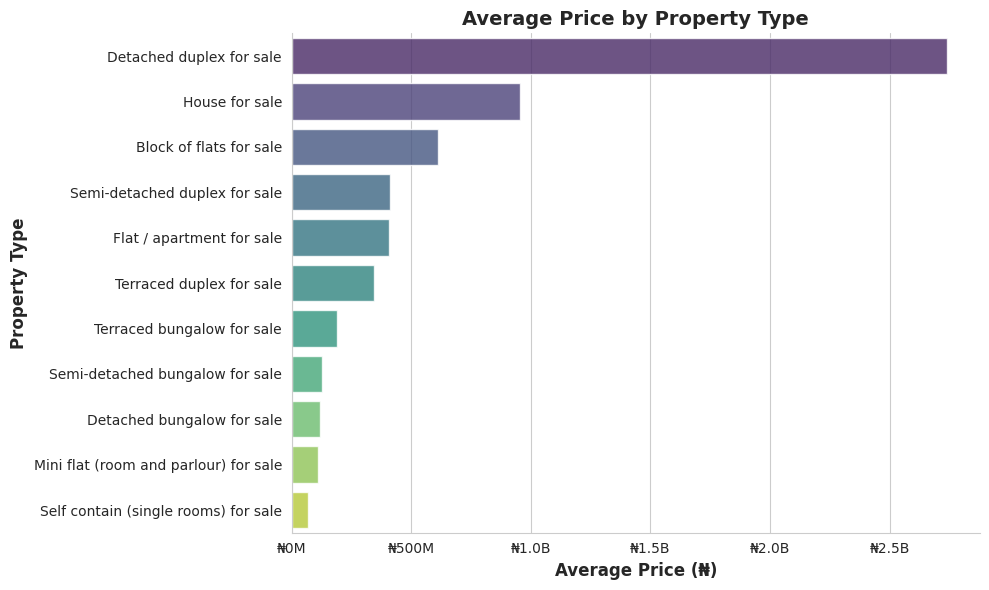

<Figure size 640x480 with 0 Axes>

In [113]:
plt.figure(figsize = (10, 6))
sns.barplot(data = property_group, x = "mean_price", y = property_group.index, palette = "viridis", orient = 'h', edgecolor = 'white', alpha = 0.8, hue=property_group.index, legend=False)
plt.title("Average Price by Property Type", fontsize = 14, fontweight = 'bold')
plt.xlabel("Average Price (₦)", fontsize = 12, fontweight = 'bold')
plt.ylabel("Property Type", fontsize = 12, fontweight = 'bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₦{x/1_000_000_000:.1f}B" if x >= 1_000_000_000 else f"₦{x/1_000_000:.0f}M"))
sns.despine()
plt.tight_layout()
plt.show()

plt.savefig("../visuals/average_price_by_property_type.png", bbox_inches='tight')

#### Average Price by Property Type

Detached duplexes are by far the most expensive property type in Lagos, with an average price of approximately ₦2.8B — nearly three times higher than the second most expensive category, houses for sale at around ₦900M. 

This suggests detached duplexes are predominantly luxury properties concentrated in high-end neighbourhoods like Ikoyi and Lekki.

At the lower end, self-contain units, mini flats, and bungalows are the most affordable property types — making them the entry point for the Lagos property market.

The wide price gap between property types confirms that **property type is a strong predictor of price** — directly answering Research Question 2.

#### 3.3 Location Analysis

In [114]:
location_group = df.groupby("Location").agg(
  mean_price = ("Price", "mean")
).sort_values(by = "mean_price", ascending = False).head(15)
location_group

,mean_price
Location,
"Ikoyi, Lagos",8.479688e+09
"Ikeja, Lagos",3.235020e+09
"Apapa, Lagos",3.020500e+09
"Ojota, Lagos",1.530000e+09
"Eko Atlantic City, Lagos",1.471429e+09
"Old Ikoyi, Ikoyi, Lagos",1.418234e+09
"Banana Island, Ikoyi, Lagos",1.344792e+09
"Parkview, Ikoyi, Lagos",1.307778e+09
"Osborne, Ikoyi, Lagos",1.232000e+09


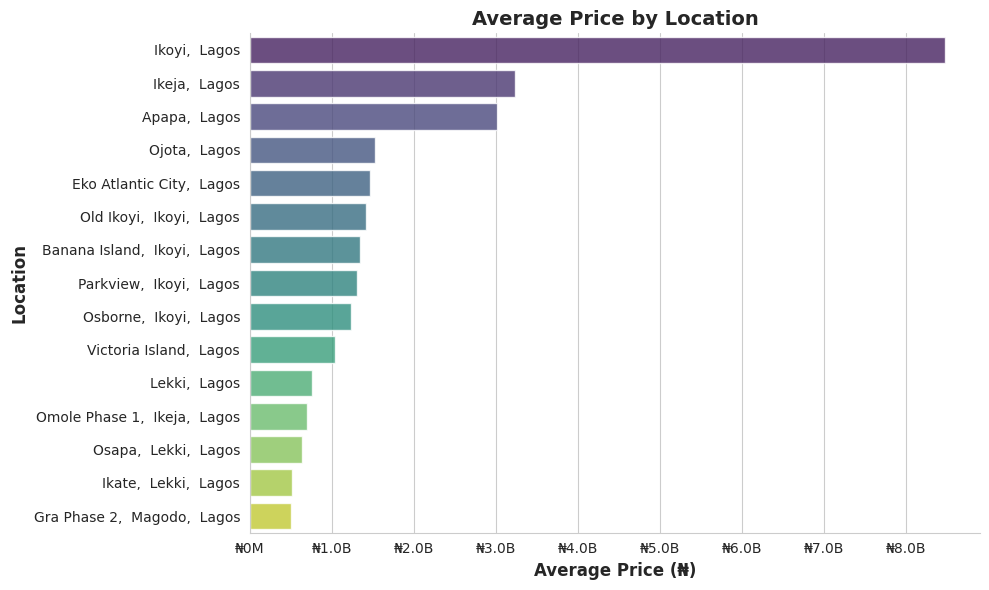

<Figure size 640x480 with 0 Axes>

In [115]:
plt.figure(figsize = (10, 6))
sns.barplot(data = location_group, x = "mean_price", y = location_group.index, palette = "viridis", orient = 'h', edgecolor = 'white', alpha = 0.8, hue = location_group.index, legend=False)
plt.title("Average Price by Location", fontsize = 14, fontweight = 'bold')
plt.xlabel("Average Price (₦)", fontsize = 12, fontweight = 'bold')
plt.ylabel("Location", fontsize = 12, fontweight = 'bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₦{x/1_000_000_000:.1f}B" if x >= 1_000_000_000 else f"₦{x/1_000_000:.0f}M"))
sns.despine()
plt.tight_layout()
plt.show()

plt.savefig("../visuals/average_price_by_location.png", bbox_inches='tight')

#### Average Price by Location

Ikoyi commands the highest average property price in Lagos at approximately ₦8.5B — nearly three times higher than the second most expensive location, Ikeja at ₦3.2B. This confirms Ikoyi's status as Lagos' most exclusive residential neighbourhood, dominated by luxury mansions and high-end apartments.

Banana Island, Parkview, Old Ikoyi and Osborne — all sub-localities within the Ikoyi axis — also feature in the top 15, reinforcing the dominance of the Ikoyi corridor in the premium property market.

Lekki and Victoria Island, while well-known luxury destinations, rank lower than expected — suggesting their average prices are moderated by a higher volume of mid-range listings compared to Ikoyi.

**Location is clearly a strong determinant of price** — directly answering Research Question 1.

#### 3.4 Bedroom and Bathroom trends

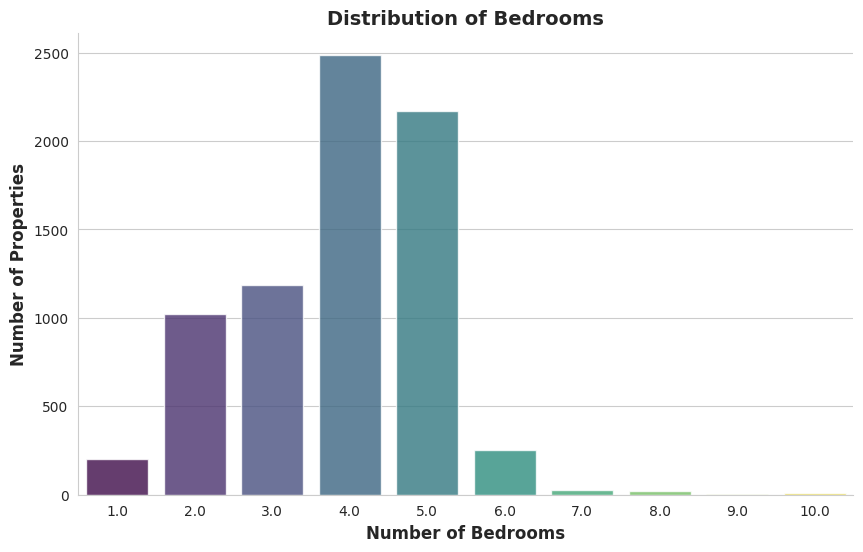

<Figure size 640x480 with 0 Axes>

In [116]:
plt.figure(figsize = (10, 6))
bedroom_nonan = df[(df["Bedrooms"].notna()) & (df["Bedrooms"] <= 10)]
sns.countplot(data = bedroom_nonan, x = "Bedrooms", palette = "viridis", edgecolor = 'white', alpha = 0.8, hue = bedroom_nonan["Bedrooms"], legend=False)
plt.title("Distribution of Bedrooms", fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Bedrooms", fontsize = 12, fontweight = 'bold')
plt.ylabel("Number of Properties", fontsize = 12, fontweight = 'bold')
sns.despine()
plt.show()

plt.savefig("../visuals/bedroom_distribution.png", bbox_inches='tight')

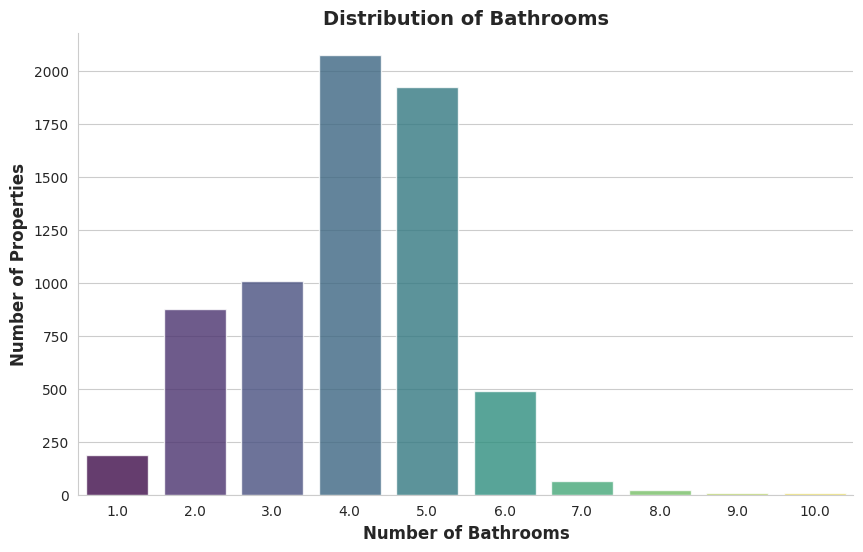

<Figure size 640x480 with 0 Axes>

In [117]:
plt.figure(figsize = (10, 6))
bathroom_nonan = df[(df["Bathrooms"].notna()) & (df["Bathrooms"] <= 10)]
sns.countplot(data = bathroom_nonan, x = "Bathrooms", palette = "viridis", edgecolor = 'white', alpha = 0.8, hue = bathroom_nonan["Bathrooms"], legend=False)
plt.title("Distribution of Bathrooms", fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Bathrooms", fontsize = 12, fontweight = 'bold')
plt.ylabel("Number of Properties", fontsize = 12, fontweight = 'bold')
sns.despine()
plt.show()

plt.savefig("../visuals/bathroom_distribution.png", bbox_inches='tight')

#### Bedroom and Bathroom Count Distribution

The Lagos property market is dominated by 4 and 5 bedroom and bathroom properties, which together account for the majority of listings. This reflects the preference for larger family homes in the Lagos real estate market.

1, 2 and 3 bedroom properties are significantly less common, suggesting the market caters more to upper-middle class and wealthy buyers than to first-time buyers or small households.

Properties with 7 bedrooms and above are rare — confirming these are niche luxury listings rather than mainstream offerings.

A typical Lagos property listed for sale has **4 bedrooms** — directly contributing to the answer for Research Question 3.

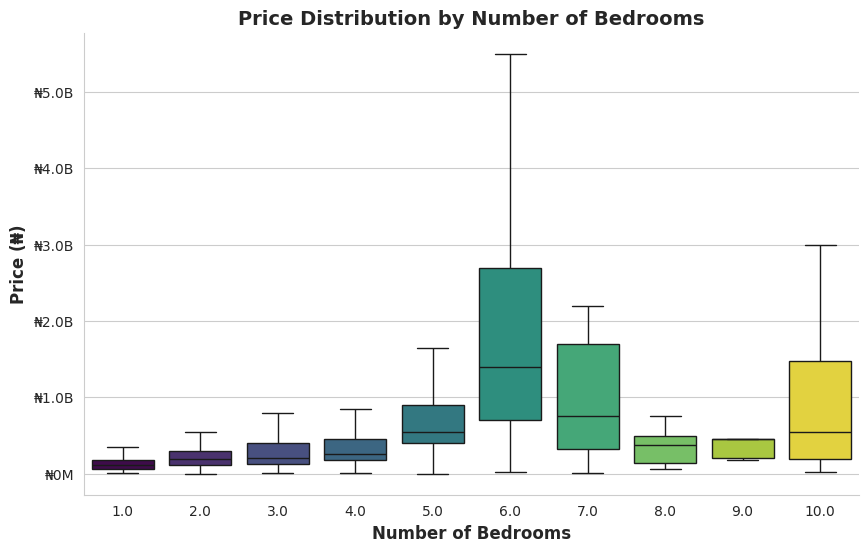

<Figure size 640x480 with 0 Axes>

In [118]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = bedroom_nonan, x = "Bedrooms", y = "Price", palette = "viridis", showfliers = False, hue = bedroom_nonan["Bedrooms"], legend=False)
plt.title("Price Distribution by Number of Bedrooms", fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Bedrooms", fontsize = 12, fontweight = 'bold')
plt.ylabel("Price (₦)", fontsize = 12, fontweight = 'bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₦{x/1_000_000_000:.1f}B" if x >= 1_000_000_000 else f"₦{x/1_000_000:.0f}M"))
sns.despine()
plt.show()

plt.savefig("../visuals/price_distribution_by_bedrooms.png", bbox_inches='tight')

#### Price Distribution by Number of Bedrooms

There is a clear visual upward trend in price as bedroom count increases up to 6 bedrooms — as the number of bedrooms increases, both the median price and price spread increase significantly.

1 to 4 bedroom properties are clustered in the lower price range below ₦500M, while 5 and 6 bedroom properties jump sharply into the ₦500M to ₦2.5B range — reflecting the luxury nature of larger homes in Lagos.

The 8 and 9 bedroom categories show unexpectedly lower prices compared to 6 and 7 bedrooms. This is likely due to a small sample size in those categories rather than a genuine market trend.

**Note** — whether bedroom count is truly driving price or whether this trend is explained by location will be examined in the correlation analysis.

#### 3.5 Feature Correlation

In [119]:
corr_matrix = df.select_dtypes(include="number").corr()
corr_matrix

,Price,Bedrooms,Bathrooms,Toilets,Parking_Space
Price,1.000000,0.018334,0.019164,0.019494,0.004015
Bedrooms,0.018334,1.000000,0.862424,0.755571,0.220736
Bathrooms,0.019164,0.862424,1.000000,0.801472,0.193821
Toilets,0.019494,0.755571,0.801472,1.000000,0.179891
Parking_Space,0.004015,0.220736,0.193821,0.179891,1.000000


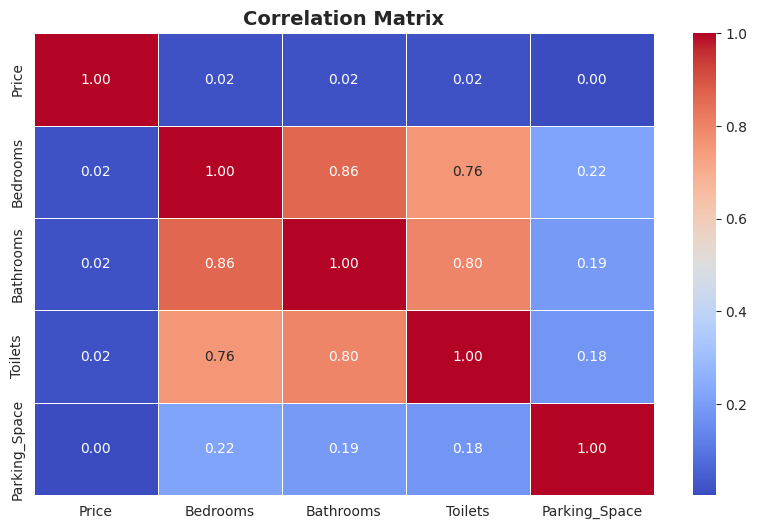

<Figure size 640x480 with 0 Axes>

In [120]:
plt.figure(figsize = (10, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", linewidths = 0.5)
plt.title("Correlation Matrix", fontsize = 14, fontweight = 'bold')
plt.show()
plt.savefig("../visuals/correlation_matrix.png", bbox_inches='tight')

#### Feature Correlation Heatmap

The correlation matrix reveals a surprising finding — none of the numeric features (bedrooms, bathrooms, toilets, parking) show meaningful correlation with price. All correlations with Price are effectively zero (0.00 to 0.02).

This suggests that in the Lagos property market, room count alone is not a reliable predictor of price. Location, property type and finishing quality are likely far stronger price drivers — factors that are harder to quantify from listing data alone.

Unsurprisingly, bedrooms, bathrooms and toilets are strongly correlated with each other (0.76 to 0.86) — more bedrooms naturally means more bathrooms and toilets.

**This directly answers Research Question 5** — property features like bedroom and bathroom count have minimal correlation with price in Lagos. Location is the dominant pricing factor.

#### 3.6 Underpriced Vs Overpriced Locations

In [121]:
price_mean = df["Price"].mean()
location_means = df.groupby("Location").agg({"Price": "mean"})
price_diff = (location_means["Price"] - price_mean).sort_values(ascending = False)
top_10 = price_diff.head(10)
bottom_10 = price_diff.tail(10)
price_diff_combined = pd.concat([top_10, bottom_10]).sort_values()
price_diff_combined = price_diff_combined[~price_diff_combined.index.duplicated()]
price_diff_combined = price_diff_combined.sort_values()

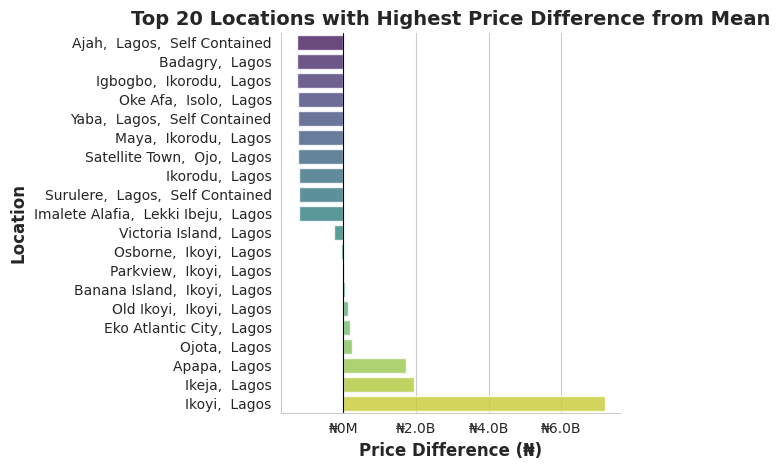

<Figure size 640x480 with 0 Axes>

In [122]:
sns.barplot(x = price_diff_combined.values, y = price_diff_combined.index, palette = "viridis", edgecolor = 'white', alpha = 0.8, orient="h", hue = price_diff_combined.index, legend=False)
plt.title("Top 20 Locations with Highest Price Difference from Mean", fontsize = 14, fontweight = 'bold')
plt.xlabel("Price Difference (₦)", fontsize = 12, fontweight = 'bold')
plt.ylabel("Location", fontsize = 12, fontweight = 'bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₦{x/1_000_000_000:.1f}B" if x >= 1_000_000_000 else f"₦{x/1_000_000:.0f}M"))
sns.despine()
plt.tight_layout()
plt.show()

plt.savefig("../visuals/top_bottom_20_locations_price_diff.png", bbox_inches='tight')

In [123]:
df.to_csv("../data/lagos_clean.csv", index=False)

#### Underpriced vs Overpriced Locations

Comparing each location's average price against the Lagos market average reveals a clear geographic divide. Premium island locations — Ikoyi, Banana Island, Parkview and Old Ikoyi — command prices significantly above the Lagos average, with Ikoyi leading at ₦7.19B above average.

On the underpriced side, mainland and suburban areas — Ikorodu, Badagry, Yaba, Surulere and Satellite Town — fall well below the Lagos average, with some as much as ₦1.28B below. These areas represent the most affordable entry points into the Lagos property market.

This stark divide between island and mainland pricing directly answers Research Question 4 — location premium in Lagos is not subtle, it is extreme and geography-driven

**Note** — this analysis is based on 29% of total available listings scraped from NigeriaPropertyCentre. A complete dataset may reveal additional patterns not captured here.

## 5. Insights & Findings

This section summarises the key findings from the exploratory analysis of 14,995 Lagos residential property listings scraped from NigeriaPropertyCentre. These insights directly answer the five research questions defined at the start of the project.

**Note**: This analysis is based on approximately 29% of total available listings of Lagos as of the time of scraping on NigeriaPropertyCentre (500 of 1,725 pages). Findings are representative of the Lagos market but not exhaustive — a complete dataset 
may reveal additional patterns not captured here.

---

### Q1 — Does location significantly affect property price?
**Yes — location is the single most powerful pricing factor in Lagos.**
Ikoyi commands an average price of ₦7.19B above the Lagos market average, while affordable mainland areas like Ikorodu, Badagry and Surulere sit over ₦1B below average. The price gap between the most expensive and most affordable locations is staggering — confirming that in Lagos, your address matters more than anything else.

---

### Q2 — Does property type influence pricing?
**Yes — significantly.**
Detached duplexes are the most expensive property type at an average of approximately ₦2.8B — nearly three times higher than the second most expensive category. At the other end, self-contain units and mini flats are the most affordable entry points into the Lagos market. Property type is a strong proxy for luxury level and target buyer segment.

---

### Q3 — What does a typical Lagos property look like?
**A typical Lagos property listed for sale has:**
- **4 bedrooms** — the most common bedroom count by a significant margin
- **Median price of ₦330M** — though the distribution is heavily right-skewed, meaning the average is pulled upward by luxury outliers
- **Property type** — most commonly a detached duplex, followed by flat/apartment and terraced duplex

The price distribution is strongly right-skewed, with the bulk of properties priced between ₦50M and ₦300M and a long tail of luxury properties extending into the billions.

---

### Q4 — Which locations appear underpriced or overpriced?
**Overpriced locations** — Ikoyi, Banana Island, Parkview, Old Ikoyi, Ikeja and Apapa command prices well above the Lagos average. These are either established luxury neighbourhoods or areas with a high concentration of premium detached duplexes inflating the average.

**Underpriced locations** — Ikorodu, Badagry, Satellite Town, Yaba, Surulere and Ajah offer properties significantly below the Lagos average — making them the most accessible areas for budget-conscious buyers.

---

### Q5 — Which features correlate most strongly with price?
**Surprisingly — none of the numeric features correlate meaningfully with price.**
Bedrooms, bathrooms, toilets and parking space all show near-zero correlation with price (0.00 to 0.02). This confirms that in Lagos, room count alone tells you almost nothing about what a property costs.

Location and property type are the dominant pricing factors — not physical features.This has important implications for the prediction model: location and property type must be encoded as features, as numeric room counts alone will produce a poor model.

---

### Key Takeaways
- **Location is everything** in Lagos real estate — the island/mainland divide is extreme and geography-driven
- **Property type signals luxury level** more than bedroom count does
- **The market is heavily skewed** toward high-end listings — the median buyer needs ₦330M minimum
- **Room count is a weak price predictor** — location and property type must anchor any prediction model
- **Data limitation** — 29% of listings were captured. Mainland areas like Surulere and Yaba may be underrepresented relative to their true market share
